### Import Modelling Libraries

In [46]:
# Core
import time
from pathlib import Path
import joblib

# Data
import pandas as pd
import numpy as np

# Models (sklearn + others)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# External gradient boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Pipeline
from sklearn.pipeline import Pipeline

# Metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Label mapping
LABEL_NAMES = {
    0: "Normal",
    1: "Leak",
    2: "Blockage"
}

# Paths
BASE_PATH   = Path.cwd().parent
SCALED_PATH = BASE_PATH / "data" / "model" / "scaled"
MODEL_PATH  = BASE_PATH / "models"

MODEL_PATH.mkdir(parents=True, exist_ok=True)

print("Imports & config loaded.")


Imports & config loaded.


### Load Scaled Data

In [47]:
# Load data that has been scaled.
# Loading the Robust Scaled data and then, switch to Standard Scaled data later for comparison.

# Load scaled data (ROBUST versions)
X_train = pd.read_csv(SCALED_PATH / "X_train_robust.csv")
X_val   = pd.read_csv(SCALED_PATH / "X_val_robust.csv")
X_test  = pd.read_csv(SCALED_PATH / "X_test_robust.csv")

y_train = pd.read_csv(SCALED_PATH / "y_train.csv").squeeze()
y_val   = pd.read_csv(SCALED_PATH / "y_val.csv").squeeze()
y_test  = pd.read_csv(SCALED_PATH / "y_test.csv").squeeze()

# Verify shapes
print("DATA SHAPES")
print("-" * 30)
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}   | y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}  | y_test : {y_test.shape}")

# Verify label balance
print("\nLABEL DISTRIBUTION")
print("-" * 30)
print("Train:\n", y_train.value_counts())
print("\nVal:\n", y_val.value_counts())
print("\nTest:\n", y_test.value_counts())

DATA SHAPES
------------------------------
X_train: (23100, 126) | y_train: (23100,)
X_val  : (4200, 126)   | y_val  : (4200,)
X_test : (4200, 126)  | y_test : (4200,)

LABEL DISTRIBUTION
------------------------------
Train:
 label
2    7700
1    7700
0    7700
Name: count, dtype: int64

Val:
 label
2    1400
1    1400
0    1400
Name: count, dtype: int64

Test:
 label
2    1400
1    1400
0    1400
Name: count, dtype: int64


# Define model pipelines

In [48]:
# Pipeline builder
def build_pipeline(model_name, estimator):
    return Pipeline([
        ("classifier", estimator)
    ])
CW = {0: 1.8, 1: 1.0, 2: 1.5}  # Normal boosted

MODELS = {
    "random_forest": build_pipeline(
        "rf",
        RandomForestClassifier(
            n_estimators=200,
            class_weight=CW,
            n_jobs=-1,
            random_state=42
        )
    ),

    "xgboost": build_pipeline(
        "xgb",
        XGBClassifier(
            n_estimators = 200,
            learning_rate = 0.1,
            num_class = 3,
            objective="multi:softmax",
            eval_metric = "mlogloss",
            scale_pos_weight=None,
            n_jobs=-1,
            random_state=42
        )
    ),

    # Linear svc does not use kernel

    "svm": build_pipeline(
        "svm",
        LinearSVC(
            C=1.0,
            class_weight=CW,
            max_iter=200,
            multi_class = "ovr",
            random_state=42

        )
    ),

    "logistic_regression": build_pipeline(
        "lr",
        LogisticRegression(
            max_iter = 1000,
            class_weight=CW,
            solver="lbfgs",
            random_state = 42
        )
    ),

    "lightgbm": build_pipeline(
        "lgbm",
        LGBMClassifier(
            n_estimators=200,
            n_jobs=-1,
            random_state=42,
            learning_rate=0.1,
            num_leaves=31,
            num_class=3,
            objective = "multiclass",
            class_weight=CW,
            min_child_samples=20,
            verbose =-1

        )
    ),

        "knn": build_pipeline("knn",
        KNeighborsClassifier(
            n_neighbors=5,
            weights="distance",
            metric="minkowski",
            n_jobs=-1
            # no class_weight — KNN doesn't support it
        )
    ),
}

print(f"Defined {len(MODELS)} models:")
for name in MODELS.keys():
    print(f"- {name}")

Defined 6 models:
- random_forest
- xgboost
- svm
- logistic_regression
- lightgbm
- knn


### Light GBM
- It is an ensemble method that uses gradient boosting method which constructs a string learner by sequentially adding weak learners in a gradient manner
- It is designed for its scalability, efficiency and high accuracy esp with large datasets.
- It decision trees that grow efficiently by minimizing memory usage and optimizing time.
- The differene with xgboost is that thgis prioritizes leaf growth over level wise growth

#### Support Vector Machine
The key idea behind the SVM algorithm is to find the hyperplane that best separates two classes by maximizing the margin between them. This margin is the distance from the hyperplane to the nearest data points (support vectors) on each side.

- Support vectors: The closest data points to the hyperplane, crucial for determining he hyper plane and the margins in SVM
- Kernel: A function that maps the data to higher dimensional space enabling SVM to handle non-linearly separable data.
- Hard Margin: A maximum-margin hyperplane that perfectly separates the data without misclassifications.
- Hyperplane: A decision boundary separating different classes in feature space and is represented by the equation wx + b = 0 in linear classification.
- Hinge Loss: A loss function penalizing misclassified points or margin violations and is combined with regularization in SVM. If the data is well classified then there are no penalties introduced.
- C: The regularization parameter that controls the trade-off between margin and misclassification error.

### Train the Models

In [49]:
# Training the six models
trained_models = {}
training_times = {}

for model_name, estimator in MODELS.items():
    print(f"Training.......{model_name}")

    start = time.time()
    estimator.fit(X_train, y_train)
    elapsed = time.time() - start

    trained_models[model_name] = estimator
    training_times[model_name] = elapsed

    print(f"Done in {elapsed:.2f} seconds.")

print("\n All Models Trained")
print(training_times)


Training.......random_forest
Done in 18.38 seconds.
Training.......xgboost
Done in 13.29 seconds.
Training.......svm
Done in 14.86 seconds.
Training.......logistic_regression
Done in 17.81 seconds.
Training.......lightgbm
Done in 6.26 seconds.
Training.......knn
Done in 0.03 seconds.

 All Models Trained
{'random_forest': 18.376438856124878, 'xgboost': 13.291810274124146, 'svm': 14.859079837799072, 'logistic_regression': 17.813661575317383, 'lightgbm': 6.263467788696289, 'knn': 0.0299837589263916}


### Evaluate All on Validation Set

In [50]:
# Evaluate the models
val_results = {}

for model_name, model in trained_models.items():

    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    macro_f1 = f1_score(y_val, y_pred, average="macro")
    leak_f1 = f1_score(y_val, y_pred, average=None)[1]

    report_dict = classification_report(y_val, y_pred, output_dict=True)
    leak_recall = report_dict["1"]["recall"]

    val_results[model_name] = {
        "accuracy": round(acc, 4),
        "macro_f1": round(macro_f1, 4),
        "leak_f1": round(leak_f1, 4),
        "leak_recall": round(leak_recall, 4),
        "train_time_s": training_times[model_name]
    }

    print(f"\n{'='*40}")
    print(f"MODEL: {model_name}")
    print(classification_report(
        y_val, y_pred,
        target_names=["Normal", "Leak", "Blockage"]
    ))

    if leak_recall < 0.70:
        print(f"WARNING: Leak recall = {leak_recall:.2f} — below 0.70")

print("\nValidation Summary:")
print(pd.DataFrame(val_results).T.sort_values(by="macro_f1", ascending=False))


MODEL: random_forest
              precision    recall  f1-score   support

      Normal       1.00      0.30      0.46      1400
        Leak       0.62      1.00      0.77      1400
    Blockage       0.55      0.60      0.58      1400

    accuracy                           0.63      4200
   macro avg       0.72      0.63      0.60      4200
weighted avg       0.72      0.63      0.60      4200


MODEL: xgboost
              precision    recall  f1-score   support

      Normal       1.00      0.21      0.34      1400
        Leak       0.58      1.00      0.73      1400
    Blockage       0.58      0.62      0.60      1400

    accuracy                           0.61      4200
   macro avg       0.72      0.61      0.56      4200
weighted avg       0.72      0.61      0.56      4200


MODEL: svm
              precision    recall  f1-score   support

      Normal       0.64      0.17      0.26      1400
        Leak       0.40      0.75      0.52      1400
    Blockage       0.73  

/home/local-host/IdeaProjects/ai-pipeline-leak-detection/ml_service/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/local-host/IdeaProjects/ai-pipeline-leak-detection/ml_service/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/local-host/IdeaProjects/ai-pipeline-leak-detection/ml_service/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no pre

In [51]:
print(trained_models["random_forest"].named_steps["classifier"].class_weight)
# Should print {0: 2.5, 1: 1.0, 2: 1.5} not "balanced"

{0: 1.8, 1: 1.0, 2: 1.5}


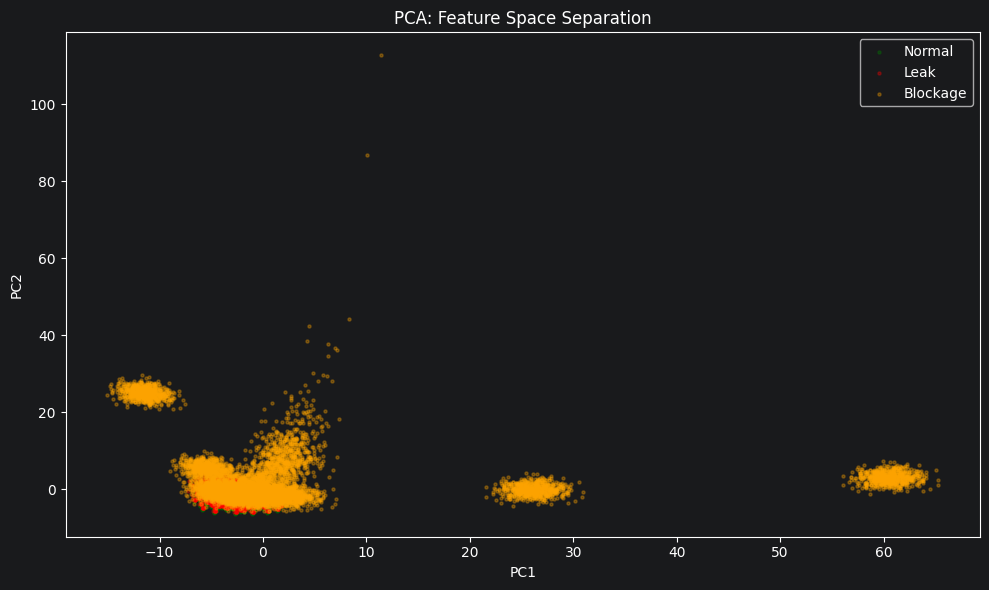

In [52]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_train)

plt.figure(figsize=(10, 6))
colors = {0: "green", 1: "red", 2: "orange"}
labels = {0: "Normal", 1: "Leak", 2: "Blockage"}

for cls in [0, 1, 2]:
    mask = y_train == cls
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1],
                c=colors[cls], label=labels[cls],
                alpha=0.3, s=5)

plt.legend()
plt.title("PCA: Feature Space Separation")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.savefig("pca_class_separation.png", dpi=150)
plt.show()

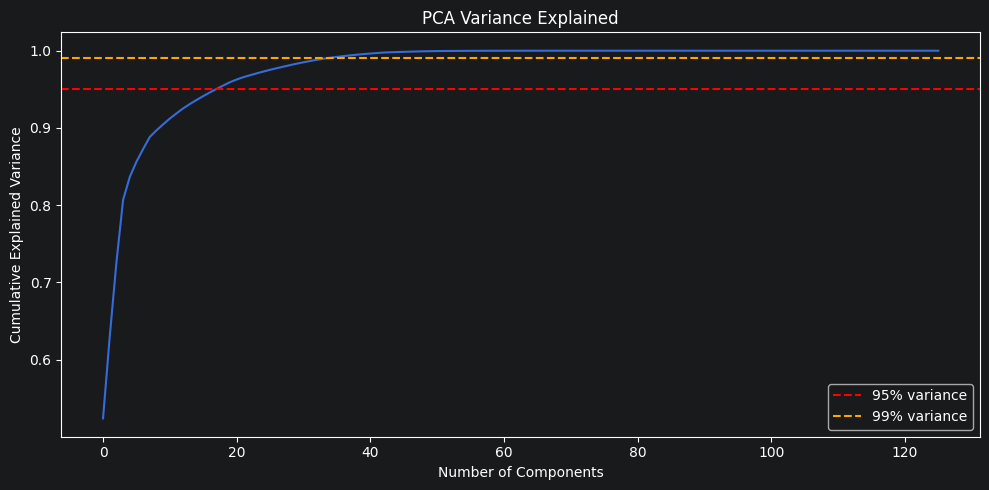

Components for 95% variance: 18
Components for 99% variance: 35


In [53]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca_full = PCA(random_state=42)
pca_full.fit(X_train)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(cumvar)
plt.axhline(0.95, color='red', linestyle='--', label='95% variance')
plt.axhline(0.99, color='orange', linestyle='--', label='99% variance')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Variance Explained")
plt.legend()
plt.tight_layout()
plt.savefig("pca_variance.png", dpi=150)
plt.show()

print(f"Components for 95% variance: {np.argmax(cumvar >= 0.95) + 1}")
print(f"Components for 99% variance: {np.argmax(cumvar >= 0.99) + 1}")

In [54]:
from sklearn.manifold import TSNE

# Use a sample — t-SNE is slow on full dataset
sample_idx = np.random.choice(len(X_train), 3000, replace=False)
X_sample = X_train.iloc[sample_idx]
y_sample = y_train.iloc[sample_idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(10, 6))
colors = {0: "green", 1: "red", 2: "orange"}
labels_map = {0: "Normal", 1: "Leak", 2: "Blockage"}

for cls in [0, 1, 2]:
    mask = y_sample.values == cls
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=colors[cls], label=labels_map[cls],
                alpha=0.5, s=10)

plt.legend()
plt.title("t-SNE: True Feature Space Structure")
plt.tight_layout()
plt.savefig("tsne_separation.png", dpi=150)
plt.show()

TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'